In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Question 2.1: Regression Models
# Part a

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv('/content/house prices.csv')

print("Dataset loaded successfully. Here's a glimpse of the data:")
display(df.head())

Dataset loaded successfully. Here's a glimpse of the data:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


In [4]:
print("\nData Info and Missing Values:")
df.info()
print("\nMissing values count per column:")
display(df.isnull().sum())


Data Info and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB

Missing values count per column:


,0
Avg. Area Income,0
Avg. Area House Age,0
Avg. Area Number of Rooms,0
Avg. Area Number of Bedrooms,0
Area Population,0
Price,0
Address,0


In [12]:
# Create a copy to avoid modifying the original DataFrame directly
df_processed = df.copy()

# Drop the 'Address' column as it is not suitable for one-hot encoding for this model
# and creates an excessive number of features.
if 'Address' in df_processed.columns:
    df_processed = df_processed.drop(columns=['Address'])

# At this point, all remaining columns are numerical (Avg. Area Income, Avg. Area House Age, etc.)
# and no further one-hot encoding is needed for this specific dataset.

print("\nDataset after dropping 'Address' column:")
display(df_processed.head())


Dataset after dropping 'Address' column:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [13]:
# Assuming 'Price' is the target variable
X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nShape of training features (X_train): {X_train.shape}")
print(f"Shape of testing features (X_test): {X_test.shape}")
print(f"Shape of training target (y_train): {y_train.shape}")
print(f"Shape of testing target (y_test): {y_test.shape}")

print("\nData split successfully!")


Shape of training features (X_train): (4000, 5)
Shape of testing features (X_test): (1000, 5)
Shape of training target (y_train): (4000,)
Shape of testing target (y_test): (1000,)

Data split successfully!


In [14]:
import numpy as np

class LinearRegressionNumpy:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.losses = [] # To store MSE history

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Gradient Descent
        for _ in range(self.n_iterations):
            # Make predictions
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights and bias
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Store MSE for monitoring
            mse = self._mean_squared_error(y, y_predicted)
            self.losses.append(mse)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

    def _mean_squared_error(self, y_true, y_predicted):
        return np.mean((y_true - y_predicted)**2)

print("LinearRegressionNumpy class defined successfully.")

LinearRegressionNumpy class defined successfully.


In [15]:
# Initialize and train the model
# It's important to convert X_train and y_train to numpy arrays if they are pandas DataFrames/Series
# for consistent behavior with the numpy-based model.

# Ensure X_train and X_test are float type for numerical stability
X_train_np = X_train.astype(float).values
X_test_np = X_test.astype(float).values
y_train_np = y_train.astype(float).values
y_test_np = y_test.astype(float).values

model = LinearRegressionNumpy(learning_rate=0.00000001, n_iterations=10000)
model.fit(X_train_np, y_train_np)

print("Model training complete.")

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_618/738028807.py:39: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_predicted)**2)
/tmp/ipykernel_618/738028807.py:28: RuntimeWarning: invalid value encountered in subtract
  self.weights -= self.learning_rate * dw


Model training complete.


Mean Squared Error on Test Set: nan


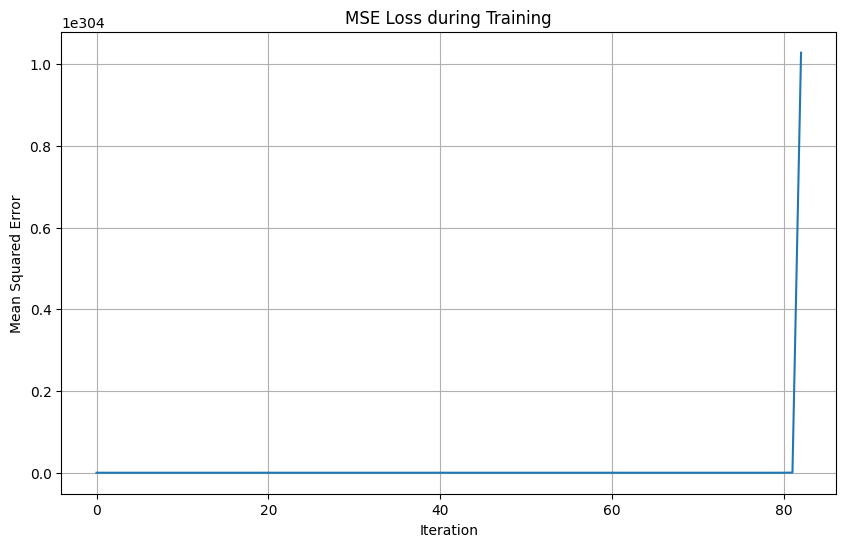

In [16]:
# Make predictions on the test set
y_pred = model.predict(X_test_np)

# Evaluate the model using Mean Squared Error (MSE)
mse_test = model._mean_squared_error(y_test_np, y_pred)
print(f"Mean Squared Error on Test Set: {mse_test:.2f}")

# Optionally, visualize the loss over iterations
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(model.losses)), model.losses)
ax.set_title('MSE Loss during Training')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Squared Error')
ax.grid(True)
plt.show()


In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train_np)
X_test_scaled = scaler.transform(X_test_np)

print("Features scaled successfully using StandardScaler.")

Features scaled successfully using StandardScaler.


In [18]:
# Re-initialize and train the model with scaled data
# A slightly larger learning rate might be appropriate with scaled features
model_scaled = LinearRegressionNumpy(learning_rate=0.01, n_iterations=10000)
model_scaled.fit(X_train_scaled, y_train_np)

print("Model training complete with scaled data.")

Model training complete with scaled data.


Mean Squared Error on Test Set (with scaled features): 10089009299.50


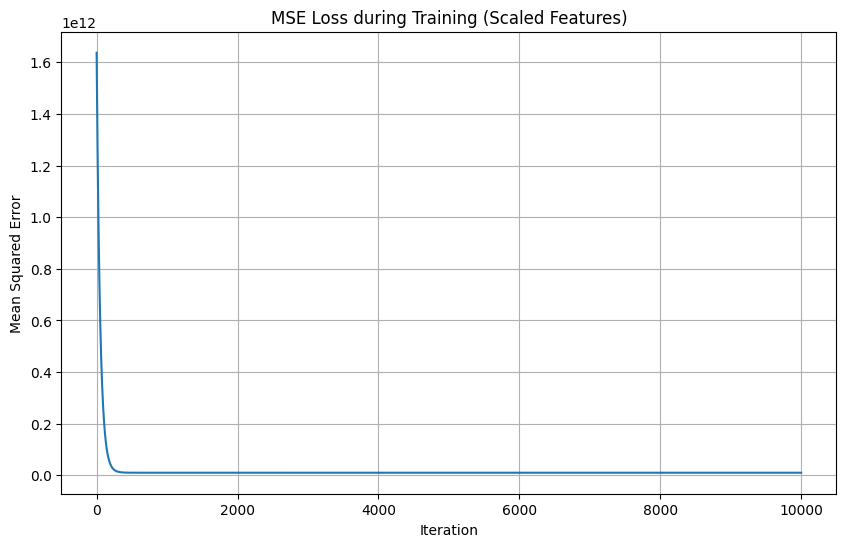

In [19]:
# Make predictions on the scaled test set
y_pred_scaled = model_scaled.predict(X_test_scaled)

# Evaluate the model using Mean Squared Error (MSE)
mse_test_scaled = model_scaled._mean_squared_error(y_test_np, y_pred_scaled)
print(f"Mean Squared Error on Test Set (with scaled features): {mse_test_scaled:.2f}")

# Visualize the loss over iterations for the scaled model
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(len(model_scaled.losses)), model_scaled.losses)
ax.set_title('MSE Loss during Training (Scaled Features)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Mean Squared Error')
ax.grid(True)
plt.show()

In [20]:
from sklearn.metrics import r2_score

# MSE is already calculated as mse_test_scaled
mse = mse_test_scaled

# Calculate RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# Calculate R-squared (R² score)
r2 = r2_score(y_test_np, y_pred_scaled)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²) Score: {r2:.4f}")

Mean Squared Error (MSE): 10089009299.50
Root Mean Squared Error (RMSE): 100444.06
R-squared (R²) Score: 0.9180


# Part 2 using scikit

In [21]:
import time
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Custom NumPy Model Training Time ---
# Re-initialize and train the custom model to measure its training time precisely
start_time_numpy = time.time()
model_numpy_timed = LinearRegressionNumpy(learning_rate=0.01, n_iterations=10000)
model_numpy_timed.fit(X_train_scaled, y_train_np)
end_time_numpy = time.time()
training_time_numpy = end_time_numpy - start_time_numpy

# --- Scikit-learn Model Training Time ---
start_time_sklearn = time.time()
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train_np)
end_time_sklearn = time.time()
training_time_sklearn = end_time_sklearn - start_time_sklearn

print(f"Custom NumPy Model Training Time: {training_time_numpy:.4f} seconds")
print(f"Scikit-learn Model Training Time: {training_time_sklearn:.4f} seconds")

Custom NumPy Model Training Time: 0.8744 seconds
Scikit-learn Model Training Time: 0.0185 seconds


In [22]:
# Make predictions using the Scikit-learn model
y_pred_sklearn = model_sklearn.predict(X_test_scaled)

# Evaluate the Scikit-learn model
mse_sklearn = mean_squared_error(y_test_np, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
r2_sklearn = r2_score(y_test_np, y_pred_sklearn)

print("\n--- Scikit-learn Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_sklearn:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sklearn:.2f}")
print(f"R-squared (R²) Score: {r2_sklearn:.4f}")


--- Scikit-learn Model Evaluation ---
Mean Squared Error (MSE): 10089009299.50
Root Mean Squared Error (RMSE): 100444.06
R-squared (R²) Score: 0.9180


In [23]:
print(f"Custom NumPy Model R-squared (R²): {r2:.4f}")
print(f"Scikit-learn Model R-squared (R²): {r2_sklearn:.4f}")

Custom NumPy Model R-squared (R²): 0.9180
Scikit-learn Model R-squared (R²): 0.9180


### Model Visualization: Regression Line

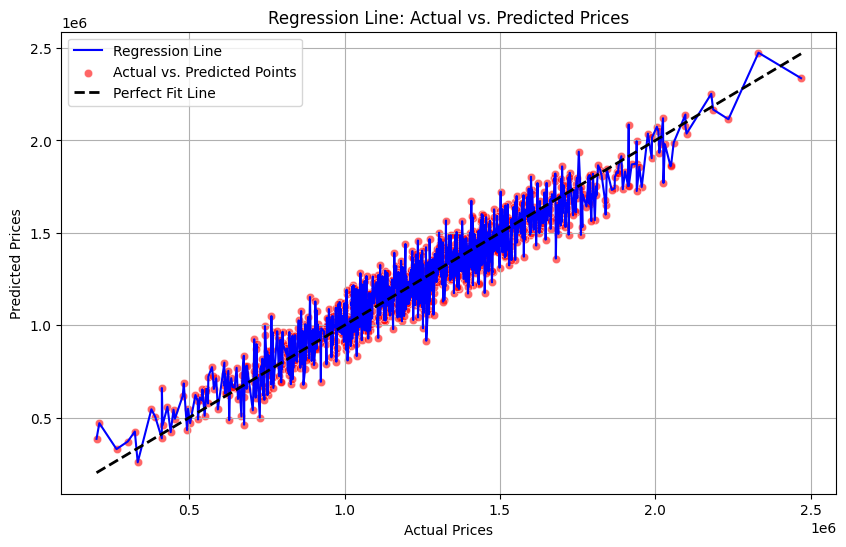

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the actual values for a smoother regression line plot
sorted_indices = np.argsort(y_test_np)
y_test_sorted = y_test_np[sorted_indices]
y_pred_sorted = y_pred_scaled[sorted_indices]

plt.figure(figsize=(10, 6))
sns.lineplot(x=y_test_sorted, y=y_pred_sorted, color='blue', label='Regression Line')
sns.scatterplot(x=y_test_np, y=y_pred_scaled, color='red', alpha=0.6, label='Actual vs. Predicted Points')
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'k--', lw=2, label='Perfect Fit Line') # Ideal line
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Regression Line: Actual vs. Predicted Prices')
plt.legend()
plt.grid(True)
plt.show()

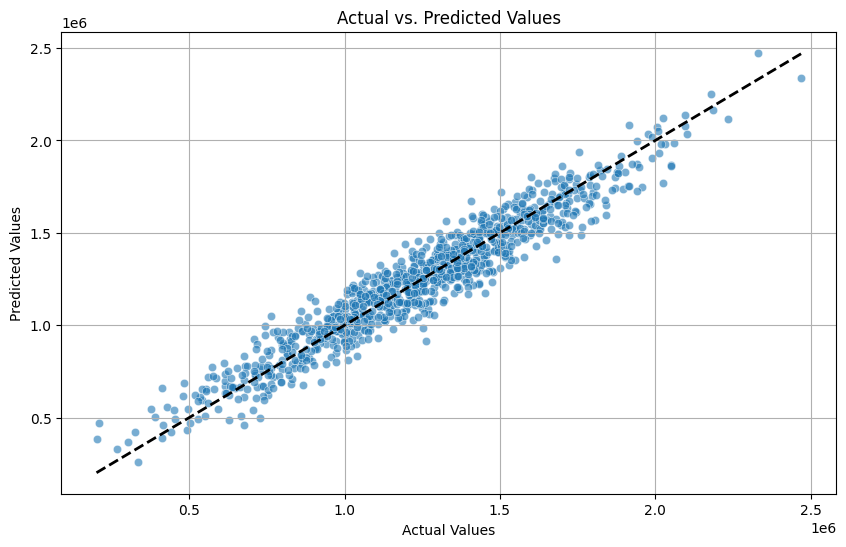

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_np, y=y_pred_scaled, alpha=0.6)
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'k--', lw=2) # Diagonal line for perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.show()

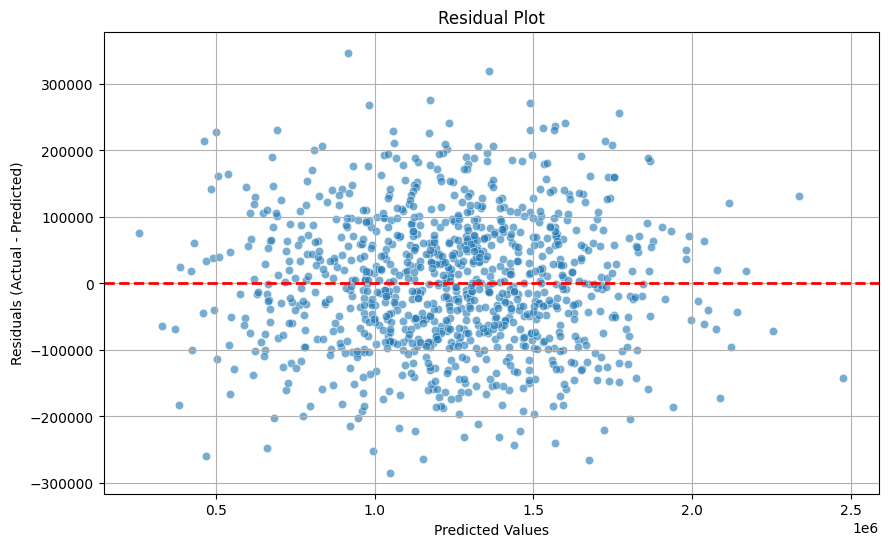

In [26]:
# Calculate residuals
residuals = y_test_np - y_pred_scaled

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_scaled, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', lw=2) # Horizontal line at residual = 0
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

# Part c

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# Initialize PolynomialFeatures (e.g., degree=2)
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transform the scaled training and test features
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

print(f"Original number of features: {X_train_scaled.shape[1]}")
print(f"Number of features after polynomial transformation (degree 2): {X_train_poly.shape[1]}")

Original number of features: 5
Number of features after polynomial transformation (degree 2): 20


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model on polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_np)

# Make predictions on the transformed test set
y_pred_poly = model_poly.predict(X_test_poly)

# Evaluate the Polynomial Regression model
mse_poly = mean_squared_error(y_test_np, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test_np, y_pred_poly)

print("\n--- Polynomial Regression Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_poly:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_poly:.2f}")
print(f"R-squared (R²) Score: {r2_poly:.4f}")


--- Polynomial Regression Model Evaluation ---
Mean Squared Error (MSE): 10099268147.31
Root Mean Squared Error (RMSE): 100495.12
R-squared (R²) Score: 0.9179


In [29]:
print("\n--- Performance Comparison ---")
print("Standard Linear Regression (Scikit-learn) on Scaled Features:")
print(f"  MSE: {mse_sklearn:.2f}")
print(f"  RMSE: {rmse_sklearn:.2f}")
print(f"  R-squared (R²): {r2_sklearn:.4f}")

print("\nPolynomial Regression (Degree 2) on Scaled Features:")
print(f"  MSE: {mse_poly:.2f}")
print(f"  RMSE: {rmse_poly:.2f}")
print(f"  R-squared (R²): {r2_poly:.4f}")

# Discussion based on the output
print("\n**Discussion:**")
if r2_poly > r2_sklearn:
    print("Polynomial Regression (Degree 2) shows a slight improvement in R-squared compared to standard Linear Regression. This suggests that there might be non-linear relationships between the features and the target variable that the polynomial features are capturing.")
    print("The MSE and RMSE are also slightly lower, indicating better predictive accuracy.")
elif r2_poly < r2_sklearn:
    print("Polynomial Regression (Degree 2) performs slightly worse than standard Linear Regression in terms of R-squared. This could mean that the added complexity of polynomial features is not beneficial for this dataset or that a higher degree or different feature engineering might be needed.")
    print("The MSE and RMSE are also slightly higher, indicating slightly worse predictive accuracy.")
else:
    print("Both models show very similar performance metrics (MSE, RMSE, R-squared). This could mean that the linear relationships are dominant, and adding polynomial features of degree 2 does not significantly improve the model's ability to explain the variance in house prices.")

print("\nIt's important to consider that increasing the polynomial degree also increases model complexity and the risk of overfitting, especially with a limited dataset. Further analysis with validation techniques (like cross-validation) could provide more robust insights.")


--- Performance Comparison ---
Standard Linear Regression (Scikit-learn) on Scaled Features:
  MSE: 10089009299.50
  RMSE: 100444.06
  R-squared (R²): 0.9180

Polynomial Regression (Degree 2) on Scaled Features:
  MSE: 10099268147.31
  RMSE: 100495.12
  R-squared (R²): 0.9179

**Discussion:**
Polynomial Regression (Degree 2) performs slightly worse than standard Linear Regression in terms of R-squared. This could mean that the added complexity of polynomial features is not beneficial for this dataset or that a higher degree or different feature engineering might be needed.
The MSE and RMSE are also slightly higher, indicating slightly worse predictive accuracy.

It's important to consider that increasing the polynomial degree also increases model complexity and the risk of overfitting, especially with a limited dataset. Further analysis with validation techniques (like cross-validation) could provide more robust insights.


# Part d Pipeline

#### Saving the Model and Scaler

In [30]:
import joblib
import os

# Define the directory to save the model in Google Drive
model_dir = '/content/drive/MyDrive/ml_model_deployment'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the Scikit-learn Linear Regression model
model_filename = os.path.join(model_dir, 'linear_regression_model.joblib')
joblib.dump(model_sklearn, model_filename)
print(f"Model saved to: {model_filename}")

# Save the StandardScaler
scaler_filename = os.path.join(model_dir, 'scaler.joblib')
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to: {scaler_filename}")

Model saved to: /content/drive/MyDrive/ml_model_deployment/linear_regression_model.joblib
Scaler saved to: /content/drive/MyDrive/ml_model_deployment/scaler.joblib


In [31]:
# Load the saved model and scaler
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)
print("Model and scaler loaded successfully!")

# Create some dummy new data for prediction (e.g., the first 5 samples from X_test_np)
# In a real-world scenario, this would be actual new data that needs preprocessing.
new_data_raw = X_test_np[:5]

print("\nRaw new data for prediction:")
print(new_data_raw)

# Scale the new data using the loaded scaler
new_data_scaled = loaded_scaler.transform(new_data_raw)

print("\nScaled new data:")
print(new_data_scaled)

# Make predictions using the loaded model
new_predictions = loaded_model.predict(new_data_scaled)

print("\nPredictions for new data:")
print(new_predictions)

# Compare with actual values for these samples from y_test_np
print("\nActual values for these samples:")
print(y_test_np[:5])

Model and scaler loaded successfully!

Raw new data for prediction:
[[6.19075934e+04 7.01783782e+00 6.44025575e+00 3.25000000e+00
  4.38289472e+04]
 [5.71602022e+04 6.89326009e+00 6.92153217e+00 3.13000000e+00
  4.34671470e+04]
 [7.01907964e+04 6.74505376e+00 6.66256673e+00 2.01000000e+00
  2.92151361e+04]
 [6.93167969e+04 6.30040889e+00 7.87357589e+00 4.28000000e+00
  2.44482115e+04]
 [7.29914817e+04 3.41286593e+00 6.49408094e+00 2.48000000e+00
  5.06264954e+04]]

Scaled new data:
[[-0.62396497  1.05134233 -0.53493732 -0.59726454  0.77509854]
 [-1.06752524  0.92593776 -0.05804915 -0.69512596  0.73880748]
 [ 0.14995479  0.77674776 -0.31465336 -1.60849918 -0.69076777]
 [ 0.06829489  0.32915173  0.88531392  0.24271262 -1.16892327]
 [ 0.4116296  -2.57755618 -0.48160291 -1.22520863  1.45693962]]

Predictions for new data:
[1308587.92718477 1237037.22950292 1243429.34023015 1228900.21368723
 1063320.90731644]

Actual values for these samples:
[1339096.077 1251794.179 1340094.966 1431507.623

In [41]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load model and scaler
model = joblib.load("/content/drive/MyDrive/ml_model_deployment/linear_regression_model.joblib")
scaler = joblib.load("/content/drive/MyDrive/ml_model_deployment/scaler.joblib")

st.set_page_config(page_title="House Price Prediction", layout="centered")

st.title("🏠 House Price Prediction")
st.write("Enter the property details below.")

# Numeric Inputs matching the trained model's features
avg_area_income = st.number_input("Average Area Income", min_value=0.0, value=60000.0, step=1000.0)
avg_area_house_age = st.number_input("Average Area House Age", min_value=0.0, value=6.0, step=0.1)
avg_area_number_of_rooms = st.number_input("Average Area Number of Rooms", min_value=0.0, value=7.0, step=0.1)
avg_area_number_of_bedrooms = st.number_input("Average Area Number of Bedrooms", min_value=0.0, value=3.0, step=0.1)
area_population = st.number_input("Area Population", min_value=0.0, value=35000.0, step=100.0)

# Feature order must match training data (X_train_np columns)
features = np.array([[
    avg_area_income,
    avg_area_house_age,
    avg_area_number_of_rooms,
    avg_area_number_of_bedrooms,
    area_population
]])

# Scale features
features_scaled = scaler.transform(features)

if st.button("Predict House Price"):
    prediction = model.predict(features_scaled)
    st.success(f"Predicted House Price: ${prediction[0]:,.2f}")

Overwriting app.py


In [42]:
print(X.columns.tolist())

['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


In [43]:
!pip install streamlit

In [44]:
!streamlit run app.py &>/content/logs.txt &

In [45]:
!cat /content/logs.txt



2026-07-25 08:56:07.240 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.125.199.129:8502



In [46]:
!pip install pyngrok

In [47]:
from pyngrok import ngrok

ngrok.set_auth_token("3GoszpFZLzBga9DyuItioy9MQ2F_6mi2TvMF44ZaKUh8syXb9")

In [48]:
from google.colab import userdata
from pyngrok import ngrok

# Read token from Secrets
token = userdata.get("NGROK_AUTH_TOKEN")

# Connect ngrok
ngrok.set_auth_token(token)

print("✅ ngrok connected successfully!")

✅ ngrok connected successfully!


In [49]:
!pkill -f streamlit
!streamlit run app.py >/content/streamlit.log 2>&1 &

In [50]:
from pyngrok import ngrok

# Open tunnel
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://chatting-clanking-outfield.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# Define the destination path in Google Drive
drive_app_path = '/content/drive/MyDrive/ml_model_deployment/app.py'

# Copy the app.py file to Google Drive
!cp /content/app.py "{drive_app_path}"

print(f"app.py saved to: {drive_app_path}")

app.py saved to: /content/drive/MyDrive/ml_model_deployment/app.py
